In [ ]:
# notebook to pdf code

In [ ]:
import pandas as pd # imports pandas
import matplotlib.pyplot as plt # allow for me to create and edit charts
from scipy import stats # allows me to use statistics tools
import numpy as np # allows me to use the entire numerical python library
df = pd.read_csv("cps_project_data.csv") # reads spreadsheet
print(df.head()) # prints the data as is
print()
# determining the number of rows and columns
print("1. The amount of rows and columns in the data: ")
print(df.shape)
print()


   YEAR  MONTH  STATEFIP  WTFINL  EARNWEEK2  AGE  SEX   OCC  UHRSWORKT  EDUC
0  2020      3        54     NaN      750.0   37    1  5610         40    73
1  2020      3        32     NaN     1250.0   52    1  4020         80    73
2  2020      3        10     NaN     1058.0   55    2  5740         40   111
3  2020      3         8     NaN     1600.0   50    1  3258         44   123
4  2020      3        34     NaN      600.0   39    2  4920         40    91

1. The amount of rows and columns in the data: 
(60000, 10)



In [ ]:
# determining the data types
print("2. The data types of the data: ")
print(df.info())
print()

2. The data types of the data: 
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   YEAR       60000 non-null  int64  
 1   MONTH      60000 non-null  int64  
 2   STATEFIP   60000 non-null  int64  
 3   WTFINL     54421 non-null  float64
 4   EARNWEEK2  60000 non-null  float64
 5   AGE        60000 non-null  int64  
 6   SEX        60000 non-null  int64  
 7   OCC        60000 non-null  int64  
 8   UHRSWORKT  60000 non-null  int64  
 9   EDUC       60000 non-null  int64  
dtypes: float64(2), int64(8)
memory usage: 4.6 MB
None



In [ ]:
# determing the value ranges
value_r = df.max(numeric_only=True) - df.min(numeric_only=True)
print("3. The range values of the data: ")
print(value_r)

3. The range values of the data: 
YEAR             5.0000
MONTH           11.0000
STATEFIP        55.0000
WTFINL       20142.0342
EARNWEEK2    13254.2300
AGE             69.0000
SEX              1.0000
OCC           9760.0000
UHRSWORKT      999.0000
EDUC           123.0000
dtype: float64


In [ ]:
# identifying which variables have special codes
special_values = df.loc[
    df["UHRSWORKT"].isin([0, 997, 999]),
    ["UHRSWORKT"]
] # saving as a variable to use later
print("4. Variables with special codes: ")
print(special_values)



4. Variables with special codes: 
       UHRSWORKT
23           997
31           997
43           997
101          997
115          997
...          ...
59875        997
59876        997
59909        997
59922        997
59985        997

[3004 rows x 1 columns]


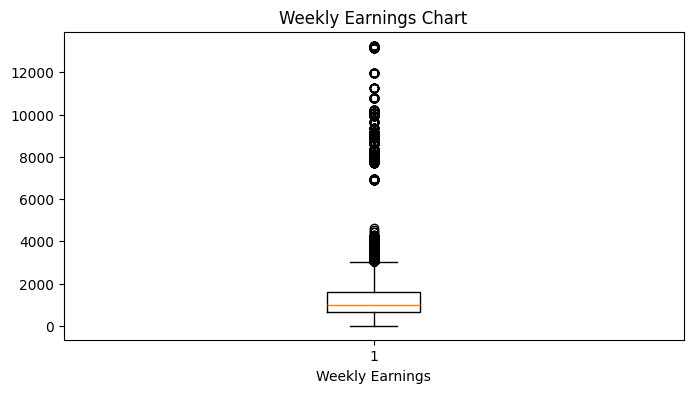

In [ ]:
# create a table or plot that reveals a data quality issue
plt.figure(figsize=(8,4))
plt.boxplot(df["EARNWEEK2"].dropna())
plt.title("Weekly Earnings Chart")
plt.xlabel("Weekly Earnings")
plt.show()

In [ ]:
# Replacing values

# replace values of 997 and 999 in UHRSWORKT with missing values
df["UHRSWORKT"] = df["UHRSWORKT"].replace([0,997, 999], np.nan)
print("1. Replacing the special characters with null values")
print(df[df["UHRSWORKT"].isna()].head(20)) # verifying those values were replaced



1. Replacing the special characters with null values
     YEAR  MONTH  STATEFIP  WTFINL  EARNWEEK2  AGE  SEX   OCC  UHRSWORKT  EDUC
23   2020      3        33     NaN      840.0   51    2  3310        NaN    92
31   2020      3        12     NaN      224.0   64    2  5400        NaN    81
43   2020      3        46     NaN     1094.0   64    1  7330        NaN    81
101  2020      3        35     NaN     1080.0   52    1  1530        NaN    81
115  2020      3         6     NaN      616.0   35    1  4220        NaN    91
136  2020      3        13     NaN      800.0   33    1  6200        NaN    20
155  2020      3        44     NaN      300.0   28    1  7640        NaN    73
176  2020      3         5     NaN     1240.0   53    2    10        NaN   111
179  2020      3        36     NaN      400.0   39    1  6600        NaN    73
200  2020      3        16     NaN     1250.0   25    1   310        NaN    73
207  2020      3        45     NaN     1330.0   49    2  2310        NaN   123

In [ ]:
# Creating columns

# create EDUC_GROUP column with 6 categories using the mapping in the variable reference
categories = [
    (df["EDUC"] >= 2) & (df["EDUC"] <= 71),
    (df["EDUC"] == 73),
    (df["EDUC"] == 81),
    (df["EDUC"].isin([91,92])),
    (df["EDUC"] == 111),
    (df["EDUC"].isin([123, 124, 125]))

]
labels = [
    "Less than High School",
    "High School Diploma",
    "Some College",
    "Associate's Degree",
    "Bachelor's Degree",
    "Graduate Degree"
]

df["EDUC_GROUP"] = np.select(categories, labels, default="N/A")
print("2. Education Groups Column: ")
print(df.EDUC_GROUP)
print()
df.head() #to show the column has been added to the data set


2. Education Groups Column: 
0          High School Diploma
1          High School Diploma
2            Bachelor's Degree
3              Graduate Degree
4           Associate's Degree
                 ...          
59995    Less than High School
59996    Less than High School
59997             Some College
59998          Graduate Degree
59999          Graduate Degree
Name: EDUC_GROUP, Length: 60000, dtype: object



,YEAR,MONTH,STATEFIP,WTFINL,EARNWEEK2,AGE,SEX,OCC,UHRSWORKT,EDUC,EDUC_GROUP
0,2020,3,54,NaN,750.0,37,1,5610,40.0,73,High School Diploma
1,2020,3,32,NaN,1250.0,52,1,4020,80.0,73,High School Diploma
2,2020,3,10,NaN,1058.0,55,2,5740,40.0,111,Bachelor's Degree
3,2020,3,8,NaN,1600.0,50,1,3258,44.0,123,Graduate Degree
4,2020,3,34,NaN,600.0,39,2,4920,40.0,91,Associate's Degree


In [ ]:
# create a SEX_LABEL column (male/female)
df["SEX_LABEL"] = df["SEX"].map({
    1: "Male",
    2: "Female"
})
print("3. Gender Column")
print(df.SEX_LABEL)
print()
df.head() #to show the column has been added to the data set

3. Gender Column
0          Male
1          Male
2        Female
3          Male
4        Female
          ...  
59995    Female
59996      Male
59997    Female
59998    Female
59999      Male
Name: SEX_LABEL, Length: 60000, dtype: object



,YEAR,MONTH,STATEFIP,WTFINL,EARNWEEK2,AGE,SEX,OCC,UHRSWORKT,EDUC,EDUC_GROUP,SEX_LABEL
0,2020,3,54,NaN,750.0,37,1,5610,40.0,73,High School Diploma,Male
1,2020,3,32,NaN,1250.0,52,1,4020,80.0,73,High School Diploma,Male
2,2020,3,10,NaN,1058.0,55,2,5740,40.0,111,Bachelor's Degree,Female
3,2020,3,8,NaN,1600.0,50,1,3258,44.0,123,Graduate Degree,Male
4,2020,3,34,NaN,600.0,39,2,4920,40.0,91,Associate's Degree,Female


In [ ]:
# create your own derived column (ideas: hourly wage - earnings/hours, age groups, full time vs part time)
min_age = df["AGE"].min()
max_age= df["AGE"].max()
print("Lowest Age: ", min_age)
print("Highest Age: ", max_age) #finding the range of ages to help create age groups
print()
category = [
    (df["AGE"] >= 16) & (df["AGE"] <= 18),
    (df["AGE"] >= 19) & (df["AGE"] <= 25),
    (df["AGE"] >= 26) & (df["AGE"] <= 64),
    (df["AGE"] >= 64) & (df["AGE"] <= 85)

]
label = [
    "Teenager",
    "Young Adult",
    "Adult",
    "Older Adult"
]

df["AGE_GROUP"] = np.select(category, label, default="N/A")
print("4. Age Groups Column: ")
print(df.AGE_GROUP)
print()
df.head() # to show the column has been added to the data set

Lowest Age:  16
Highest Age:  85

4. Age Groups Column: 
0              Adult
1              Adult
2              Adult
3              Adult
4              Adult
            ...     
59995       Teenager
59996       Teenager
59997          Adult
59998    Older Adult
59999          Adult
Name: AGE_GROUP, Length: 60000, dtype: object



,YEAR,MONTH,STATEFIP,WTFINL,EARNWEEK2,AGE,SEX,OCC,UHRSWORKT,EDUC,EDUC_GROUP,SEX_LABEL,AGE_GROUP
0,2020,3,54,NaN,750.0,37,1,5610,40.0,73,High School Diploma,Male,Adult
1,2020,3,32,NaN,1250.0,52,1,4020,80.0,73,High School Diploma,Male,Adult
2,2020,3,10,NaN,1058.0,55,2,5740,40.0,111,Bachelor's Degree,Female,Adult
3,2020,3,8,NaN,1600.0,50,1,3258,44.0,123,Graduate Degree,Male,Adult
4,2020,3,34,NaN,600.0,39,2,4920,40.0,91,Associate's Degree,Female,Adult


In [ ]:
# descriptive statistics: find the mean, median, standard deviation, and quartiles of EARNWEEK2 overall and within groups (using groupby)
# -- comment why the mean and median differ
print("1. Finding the averages and quartiles for EARNWEEK2: ")
print(df["EARNWEEK2"].describe())
print()
avgage = df.groupby("AGE_GROUP")["EARNWEEK2"].describe()
avgedu = df.groupby("EDUC_GROUP")["EARNWEEK2"].describe()
print("Average Earnings by Age Group (per week): ")
print(avgage)
print()
print("Average Earnings by Education (per week): ")
print(avgedu)


1. Finding the averages and quartiles for EARNWEEK2: 
count    60000.000000
mean      1299.998639
std       1258.559946
min          4.000000
25%        640.000000
50%       1000.000000
75%       1600.000000
max      13258.230000
Name: EARNWEEK2, dtype: float64

Average Earnings by Age Group (per week): 
               count         mean          std  min    25%     50%     75%  \
AGE_GROUP                                                                    
Adult        47209.0  1430.692716  1307.215231  4.0  732.0  1116.0  1730.0   
Older Adult   4403.0  1107.501242  1254.169603  4.0  420.0   800.0  1360.0   
Teenager      1526.0   308.786769   257.490077  4.0  150.0   240.0   376.0   
Young Adult   6862.0   744.798792   634.021964  4.0  404.0   640.0   900.0   

                  max  
AGE_GROUP              
Adult        13258.23  
Older Adult  13258.23  
Teenager      3000.00  
Young Adult  13258.23  

Average Earnings by Education (per week): 
                         count       

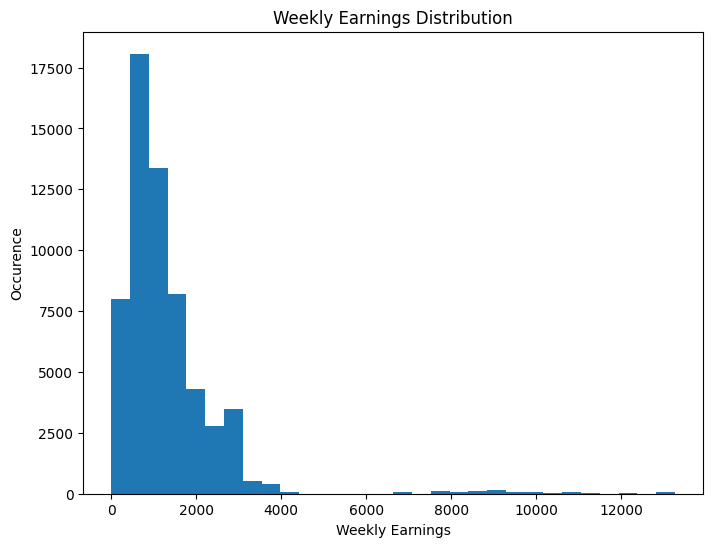

In [ ]:
# EDA: (AT LEAST 4 DIFFERENT PLOT TYPES) each with a title, labeled axes, and one sentence of interpretation using different variables
# -- 1 chart must be a pareto chart
# ---- examples: worker counts by education group or state: what share of workers fall in the top few categories

# Histogram
# Visual of weekly earnings
plt.figure(figsize=(8,6))
plt.hist(df["EARNWEEK2"], bins=30)
plt.title("2. Weekly Earnings Distribution")
plt.xlabel("Weekly Earnings")
plt.ylabel("Occurence")
plt.show()


<Figure size 700x600 with 0 Axes>

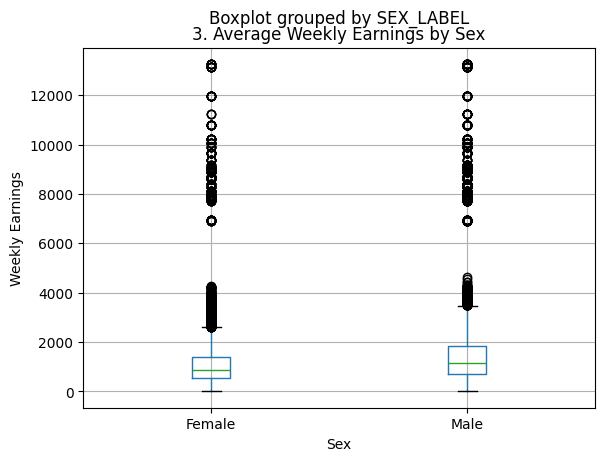

In [ ]:
# Box plot
# Average earnings by sex

plt.figure(figsize=(7,6))
df.boxplot(column="EARNWEEK2", by="SEX_LABEL")
plt.title("3. Average Weekly Earnings by Sex")
plt.xlabel("Sex")
plt.ylabel("Weekly Earnings")
plt.show()

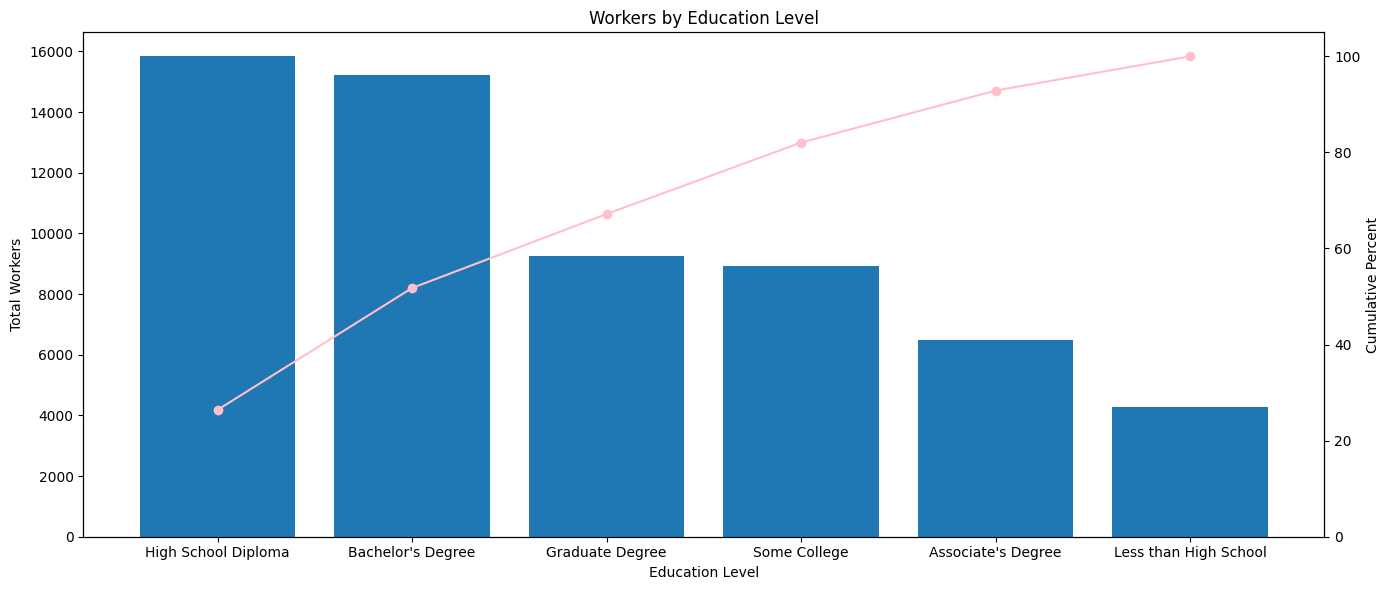

In [ ]:
# Pareto Chart
# Largest industries
pareto = (
    df["EDUC_GROUP"]
    .value_counts()
    .reset_index()
)
pareto.columns = ["Education Level", "Count"]
pareto = pareto.sort_values("Count", ascending=False) # sorting greatest to least
pareto["Percent"] = pareto["Count"] / pareto["Count"].sum() * 100
pareto["Cumulative Percent"] = pareto["Percent"].cumsum()

fig, ax = plt.subplots(figsize=(14,6))
ax.bar(pareto["Education Level"], pareto["Count"])
ax.set_ylabel("Total Workers")
ax.set_xlabel("Education Level")
ax.set_title("Workers by Education Level")
ax2 = ax.twinx()
ax2.plot (
    pareto["Education Level"],
    pareto["Cumulative Percent"],
    color="pink",
    marker="o"
)
ax2.set_ylabel("Cumulative Percent")
ax2.set_ylim(0, 105)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

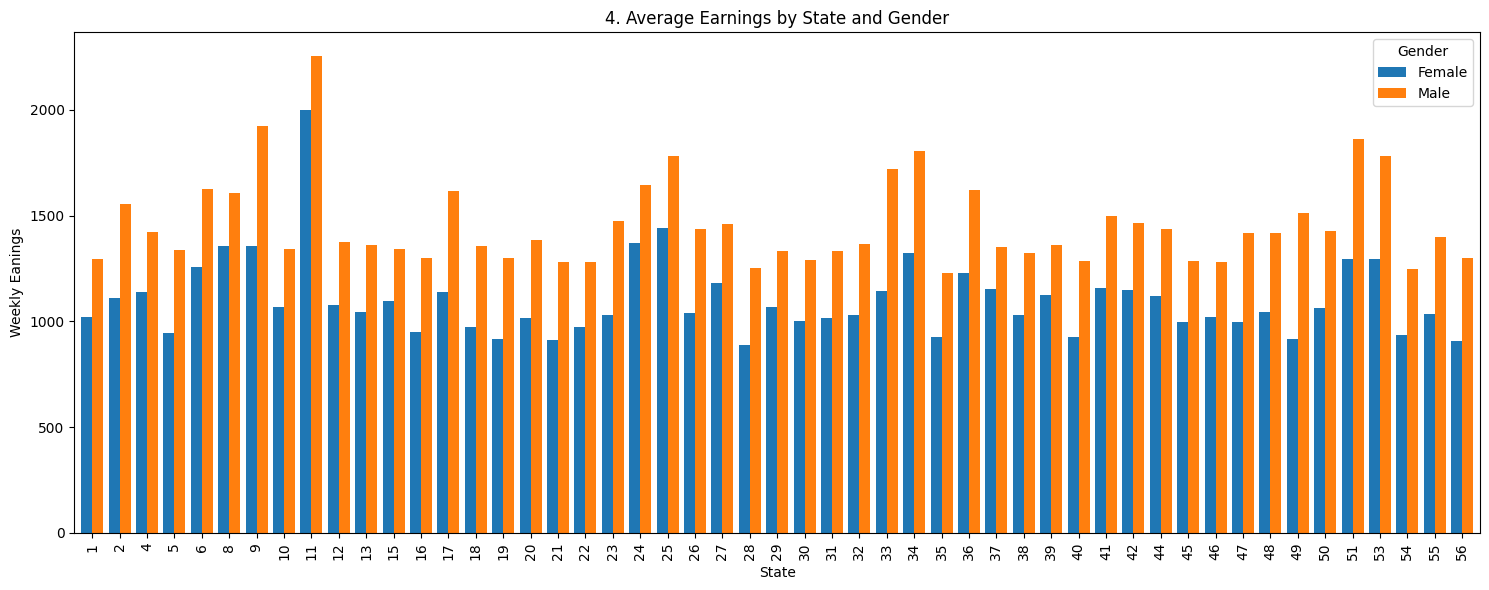

In [ ]:
# Bar Chart
# Creating a new variable that'd compare state by gender
sex_state = (
    df.groupby(["STATEFIP", "SEX_LABEL"])["EARNWEEK2"]
    .mean()
    .unstack()
)

# Creating the bar plot
sex_state.plot(
    kind="bar",
    figsize=(15,6),
    width=0.8
)
plt.title("5. Average Earnings by State and Gender")
plt.xlabel("State")
plt.ylabel("Weekly Eanings")
plt.legend(title="Gender")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Infrential Statistics: Compute these with a stated hypothesis or interpretation and a plain english conclusion
# --- a 95% confidence interval for mean weekly earnings
confident = stats.t.interval(
    confidence=0.95,
    df=len(df["EARNWEEK2"]) - 1,
    loc=df["EARNWEEK2"].mean(),
    scale=stats.sem(df["EARNWEEK2"])
)
print("6. 95% Confidence Level: ")
print(f"{confident[0]:.2f}, {confident[1]:.2f}")


1. 95% Confidence Level: 
1289.93, 1310.07


In [ ]:
# --- a two sample t test comparing earnings of men and women (report p value)
t_stat, p_value = stats.ttest_ind(
    df.loc[df["SEX_LABEL"] == "Male", "EARNWEEK2"],
    df.loc[df["SEX_LABEL"] == "Female", "EARNWEEK2"],
    equal_var=False
)
print("7a. T-Statistic: ", t_stat)
print("7b. P-Value: ", p_value)


2a. T-Statistic:  34.740395871578556
2b. P-Value:  1.114181487345185e-261


In [ ]:
# Removing missing values
scrub = df[["UHRSWORKT", "EARNWEEK2"]].dropna()

# --- a correlation coefficient (with test) between hours and earnings
corr, p_value = stats.pearsonr(
    scrub["UHRSWORKT"],
    scrub["EARNWEEK2"]
)
print("8a. Correlation: ", corr)
print("8b. P-Value: ", p_value)

Correlation:  0.31750199289022885
P-Value:  0.0
